# 🚗 Predicting Car Prices with Machine Learning

Welcome, data explorers! 👩‍💻👨‍💻🚀

Imagine you're browsing through a car dealership’s website and wondering — *"Why is this car more expensive than that one?"* 🤔  
Well, today **you’re the data scientist behind the scenes**, building a model that helps answer exactly that.

In this case study, you and your team will work on an **end-to-end machine learning project** to **predict car prices** based on various features like the model, year, mileage, fuel type, and more. We'll be using a real-world dataset from the automotive market — noisy, messy, and full of patterns waiting to be discovered. 🧠📊

You'll walk through the full ML pipeline:  
- Cleaning and preprocessing the data 🧹  
- Exploring the hidden relationships 🔍  
- Building and tuning regression models 🛠️  
- Evaluating how well your model performs 📈  
- And maybe... deploying it? (ambitious, but hey — dream big!)

By the end of this notebook, you’ll have built a model that can **predict the price of a car**, and more importantly, you'll understand how to tackle real-world machine learning problems from scratch.

Let’s rev up our engines and start predicting! 🏁💥


#### First, let's take a look at our dataset

In [16]:

import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/predict_prices_dataset.csv')
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi
5,A1,2016,13900,Automatic,32260,Petrol,30,58.9,1.4,audi
6,A6,2016,13250,Automatic,76788,Diesel,30,61.4,2.0,audi
7,A4,2016,11750,Manual,75185,Diesel,20,70.6,2.0,audi
8,A3,2015,10200,Manual,46112,Petrol,20,60.1,1.4,audi
9,A1,2016,12000,Manual,22451,Petrol,30,55.4,1.4,audi


#### 2. Explore the Dataset (EDA - Exploratory Data Analysis)
Understand the structure and content:

Shape of the dataset

Data types

Missing values

Statistical summary

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  str    
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  str    
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  str    
 6   tax           72435 non-null  int64  
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 5.5 MB


In [18]:
# Summary statistics
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000
mean,2017.073666,16579.987506,23176.517057,116.953407,55.852480,1.635650
std,2.101252,9299.218027,21331.515562,64.045533,17.114391,0.561535
min,1996.000000,99.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10175.000000,7202.500000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17531.000000,145.000000,55.400000,1.600000
75%,2019.000000,20361.000000,32449.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


#### Let's get some insights

🔧 Year: 
- Mean year of cars is ~2017, with a range from 1996 to 2020.
- 75% of the cars are from 2016 or newer, indicating the dataset is mostly composed of recent vehicles.
- The standard deviation (~2.1 years) shows low year variability — mostly modern cars.

💰 Price
- Car prices range from as low as £495 to £145,000 — this is a huge spread, likely including luxury and budget models.
- The average price is around £16,580, with a median of £14,495, suggesting a right-skewed distribution (some very expensive outliers).

🛣️ Mileage
- Mileage spans from 0 to 323,000 miles — a massive range.
- Median mileage is around 17,531, and the mean is 23,176, again showing a right-skewed distribution (many high-mileage cars).

💸 Tax
- Tax ranges from £0 to £580, with a median of £145, which likely reflects common tax bands.
- Mean tax is ~£117, and 75% of cars fall below £145 — outliers should be reviewed here as well.

⛽ MPG (Miles per Gallon)
- Extremely wide range from 0.3 to 470.8 MPG — the upper value is almost certainly an anomaly or data entry error (possibly electric vehicles with an equivalent mpg).
- Median of 55.4 MPG, and average of ~55.85, suggesting mostly fuel-efficient vehicles.

🔧 Engine Size
- Engine sizes range from 0.0 to 6.6 liters, with median = 1.6L, which aligns with common car engines.
- Some 0.0 engine sizes might indicate missing or erroneous values.
- Values above 4.0L likely belong to high-performance/luxury cars.

#### Do we have missing values??

In [19]:
# Check for missing values
df.isnull().sum()
# df.isnull().mean() * 100
# df.fillna(0).count()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

###### Handling Missing Values – Quick Decision Guide

---

###### 1) Identify Feature Type
- **Categorical (`make`, `model`)** → Mode, `"Unknown"`, or predictive modeling  
- **Numerical (`price`, `mileage`, `engineSize`)** → Mean/Median, group-wise stats, or regression/KNN  
- **Ordinal (e.g., condition 1–5)** → Median or interpolation  

---

###### 2) Check Missingness Percentage
- **<5%** → Simple imputation (mean/median/mode)  
- **5–30%** → Group-wise or model-based imputation  
- **>30%** → Consider dropping or advanced methods  

---

###### 3) Determine Missingness Mechanism
- **MCAR** (*Completely Random – e.g., data entry errors*) → Mean/median (num), Mode (cat)  
- **MAR** (*Depends on other features – e.g., mileage missing in new cars*) → Group-wise, Regression, or KNN  
- **MNAR** (*Depends on the value itself – e.g., high-priced cars hiding price*) → Keep as `NaN`, or add `"missing"` flag  

---

###### 4) Check Data Ordering
- **Sequential/Time-series** → FFILL/BFILL **within groups only**  
- **Unordered (typical listings)** → Prefer statistical or model-based methods; **avoid FFILL/BFILL**  

---

###### 5) Quick Reference Table

| Situation                | Recommended Method                          |
|---------------------------|---------------------------------------------|
| Categorical, low missing  | Mode or `"Unknown"` category                |
| Numerical, MCAR           | Mean or median                              |
| Numerical, MAR            | Group-wise median/mean, KNN, or regression  |
| Numerical, MNAR           | Keep as `NaN` or add `"missing"` flag       |
| Sequential data           | FFILL/BFILL within same group only          |

---

###### 6) Best Practices
✔ Analyze missingness before imputing  
✔ Group by similar characteristics (`make`, `model`) when filling  
✔ Never propagate values across unrelated groups  
✔ Test model performance **with & without** imputation  

---


#### Load dataset again to see it here

In [20]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0,78.4,1.6,Hyundai
72431,I40,2015,7830,Manual,59508,Diesel,30,65.7,1.7,Hyundai
72432,I10,2017,6830,Manual,13810,Petrol,20,60.1,1.0,Hyundai
72433,Tucson,2018,13994,Manual,23313,Petrol,145,44.8,1.6,Hyundai


##### Ok, now take am moment to inspect the data closely. Which is the target variable? -in our case, the price. What car brands do we have, models, what fuel type corresponds to what model, and so on. 
##### The best way to do this is of course, using visual types of plots! 

📊 1. Distribution of Car Prices
Shows price skewness and outliers.

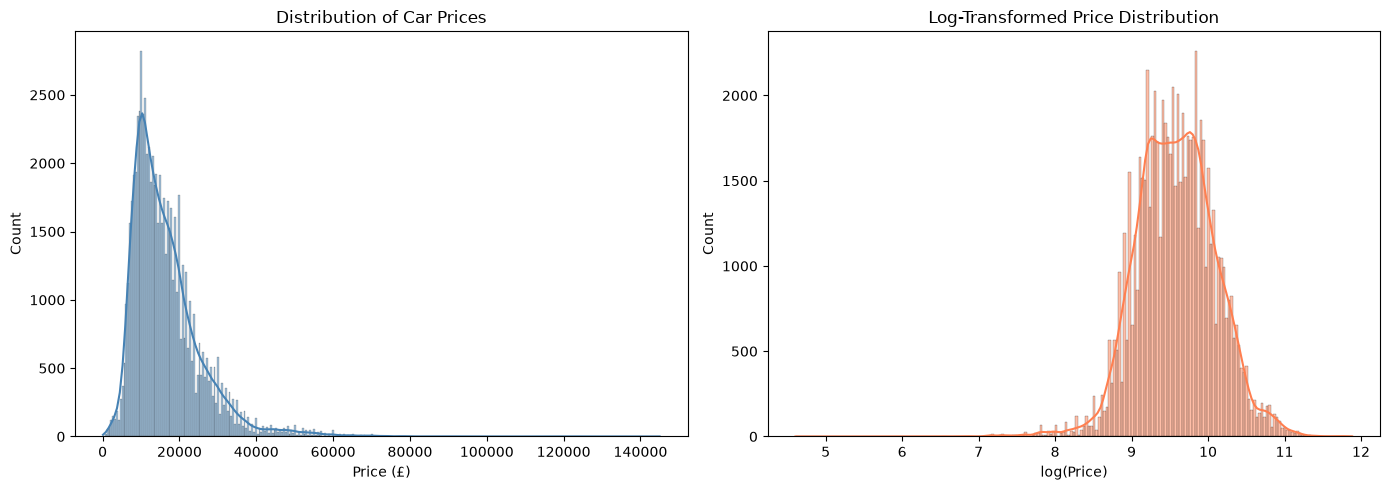

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], bins="auto", kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Car Prices')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Count')

sns.histplot(np.log1p(df['price']), bins="auto", kde=True, ax=axes[1], color='coral')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Conclusions :

*The price distribution is right-skewed which means the mode (peak) is around 
£10,000–£15,000, and most cars are concentrated below £30,000. There is a 
long tail extending to the right with rare cars priced between 
£60,000–£140,000, which are outliers. On the other end, cars priced 
under £500 are suspicious — likely data entry errors or scrap vehicles.*

*For the regression model, this skewness is problematic: outliers can 
disproportionately influence predictions. Possible solutions: 
log-transforming the price to make the distribution more symmetric, 
removing outliers, or keeping them if we're interested in the premium 
segment as well.*

🧼 2. Boxplot of Price by Transmission Type
Compare prices across automatic vs manual cars.

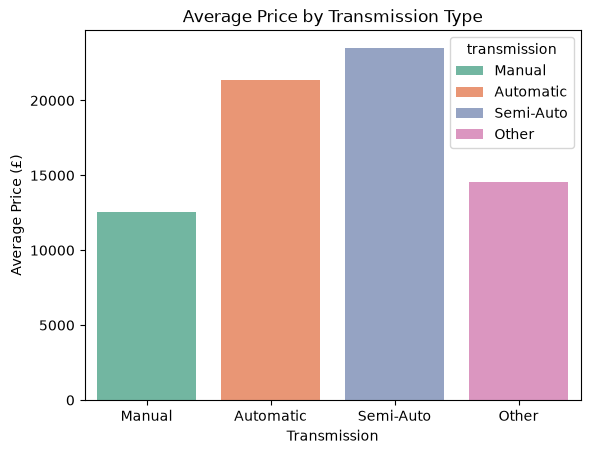

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use 'hue' to apply the palette per category
sns.barplot(
    x='transmission',
    y='price',
    data=df,
    hue='transmission',
    palette='Set2',
    errorbar=None,              
    legend=True             
)

plt.title('Average Price by Transmission Type')
plt.ylabel('Average Price (£)')
plt.xlabel('Transmission')
plt.xticks(rotation=0)
plt.show()

## Conclusions :

*The average price varies clearly by transmission type: Semi-Auto (~£24k) > 
Automatic (~£19k) > Manual (~£12k), with Other sitting somewhere in 
the middle at a mediocre price.*

*This seems to match reality. Manuals are the older, more basic tech, so it 
makes sense they cost less. Automatic is a compromise level, and Semi-Auto is 
the newer stuff — that's where the premium price comes from. The "Other" 
category isn't really popular with car buyers, which is probably why the price 
sits in that mediocre zone.*

*What this tells us is that the transmission classes ARE relevant for the 
model's predictions, but not necessarily in a direct way. For example, a 
new car — yes, it probably has semi-auto, but because it's new it also has 
low mileage, precisely because it's new. So transmission is kind of a **proxy** 
for other things (age, mileage, brand tier). A good model with access to all 
features will be able to figure out the actual unique contribution of 
transmission on its own.*



⛽ 3. Boxplot of Price by Fuel Type
Helps assess how fuel type affects car pricing.

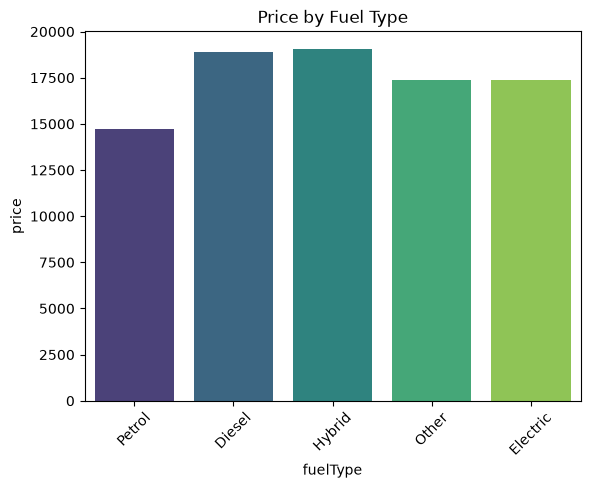

In [23]:


sns.barplot(x='fuelType', y='price', data=df, hue='fuelType',         
    palette='viridis',
    errorbar=None,              
    legend=False )
plt.title('Price by Fuel Type')
plt.xticks(rotation=45)
plt.show()

##  Conclusions :


*Right off the bat I can see that Petrol cars have the lowest prices. My 
intuition is that petrol engines are the most common and cheapest to produce, 
so they end up on entry-level and mid-range cars — that's where the low price 
comes from.*

*Diesel engines are actually just as old as petrol 
ones, but they're more complex and more expensive to build (higher 
pressures, turbo, direct injection), and they usually end up on bigger cars, 
SUVs and fleet vehicles — so the higher price makes sense.*

*Hybrid is the most expensive, and here the "new tech = expensive" logic is valid. 
Hybrids combine a combustion engine with an electric motor 
and battery, which is genuinely newer and pricier technology. Plus, hybrids 
tend to appear on premium brands (Lexus, Audi, higher-tier Toyota), so 
there's probably a confounding effect here too — it's not just the fuel 
type driving the price, but the whole premium segment they come with.*

*The "Other" category sits somewhere in the middle, which was expected — 
it probably includes Electric or rare combinations, a small heterogeneous 
group.*

🏷️ 4. Average Price per Car Make
Top 15 brands only for readability.


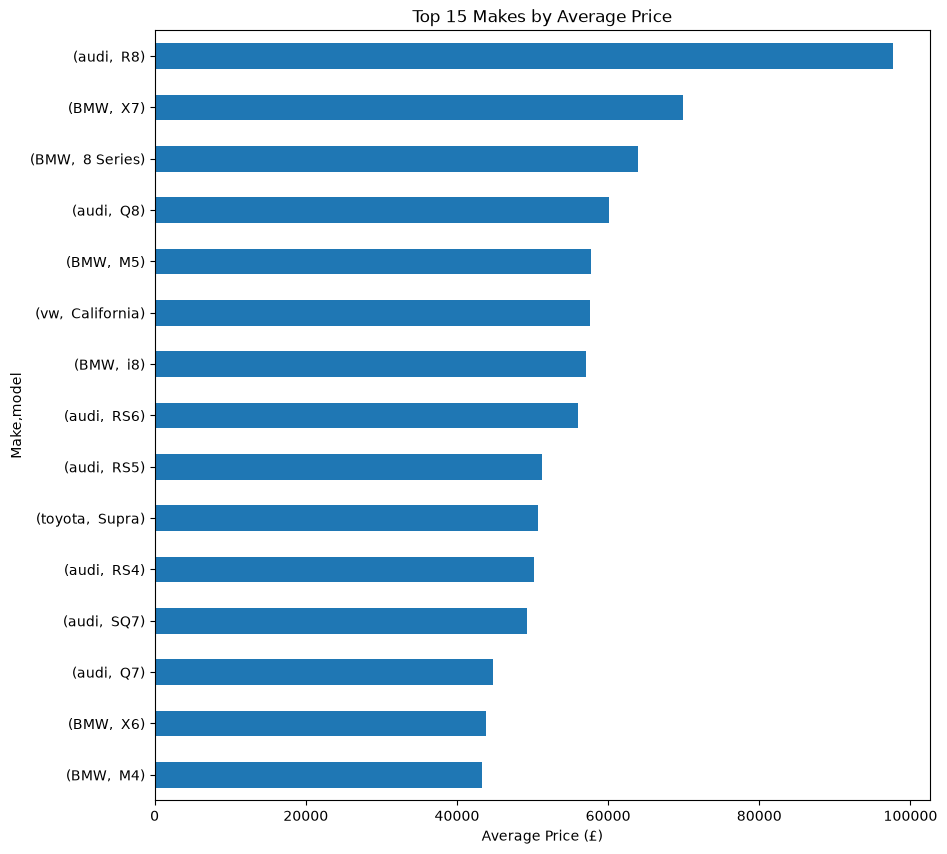

In [24]:
avg_price_by_make = df.groupby(['Make', 'model'])['price'].mean().sort_values(ascending=False).head(15)
avg_price_by_make.plot(kind='barh', figsize=(10, 10))
plt.xlabel('Average Price (£)')
plt.title('Top 15 Makes by Average Price')
plt.gca().invert_yaxis()
plt.show()

##  Conclusions : 


*For this plot, things are pretty simple: premium brands like Audi, BMW 
and Mercedes dominate the top of the list, mostly with their SUVs 
(X5, X6, Q7) and sports/supercars (Audi R8). The less premium or 
less prestigious the brand, the lower the average price drops — 
proportionally.*

*One important thing I noticed: it's not just about the brand, it's about 
the specific model within the brand. For example, Audi has both the 
A1 (~£10k) and the R8 (~£70k) — same brand, huge price difference. 
So the model itself carries a lot of information, maybe even more than 
the make alone. This has an implication for the ML model: the model column has high 
cardinality. This noise may have a negative impact when training, such as overfitting.*


📈 5. Scatterplot of Mileage vs. Price
See depreciation pattern as mileage increases.

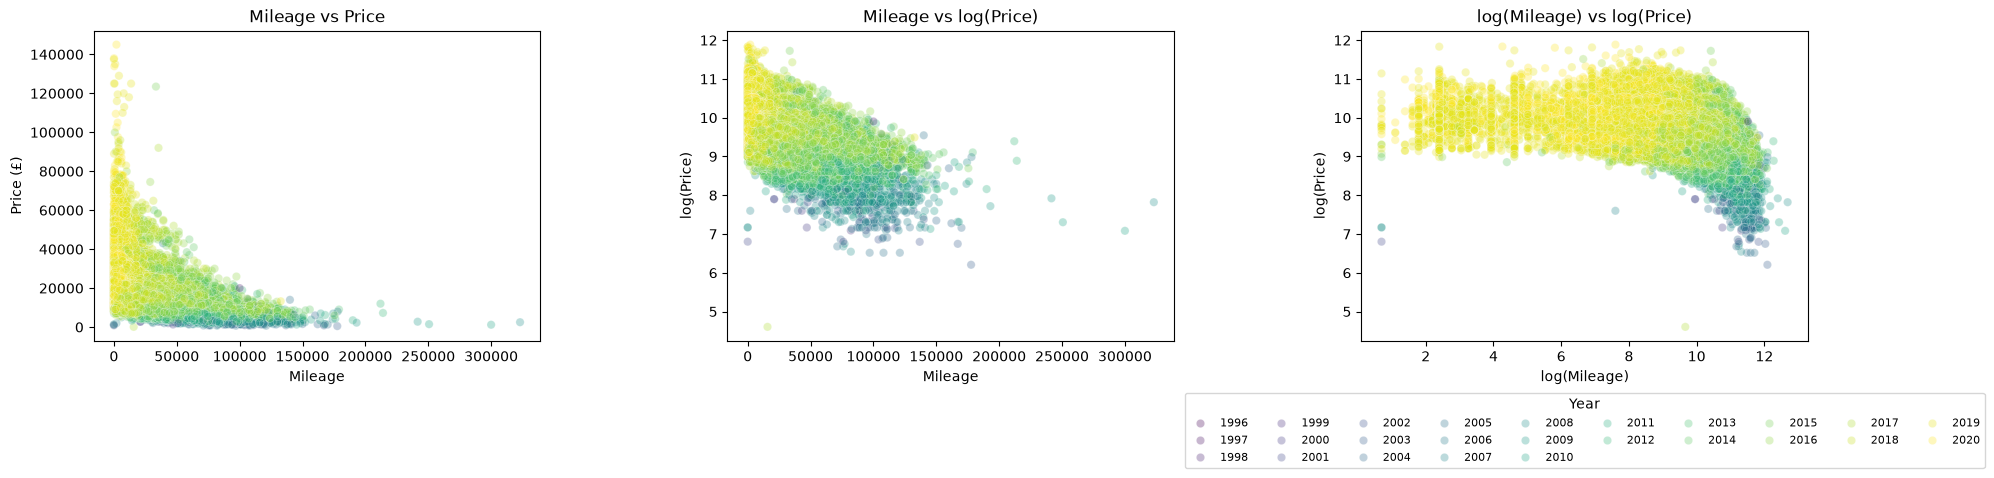

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.scatterplot(x='mileage', y='price', data=df, alpha=0.3, hue='year', palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('Mileage vs Price')
axes[0].set_xlabel('Mileage')
axes[0].set_ylabel('Price (£)')

sns.scatterplot(x='mileage', y=np.log1p(df['price']), data=df, alpha=0.3, hue='year', palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('Mileage vs log(Price)')
axes[1].set_xlabel('Mileage')
axes[1].set_ylabel('log(Price)')

sns.scatterplot(x=np.log1p(df['mileage']), y=np.log1p(df['price']), data=df, alpha=0.3, hue='year', palette='viridis', ax=axes[2], legend='full')
axes[2].set_title('log(Mileage) vs log(Price)')
axes[2].set_xlabel('log(Mileage)')
axes[2].set_ylabel('log(Price)')

axes[2].legend(title='Year', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=10, fontsize=8)

plt.tight_layout()
plt.show()

##  Conclusions 

*The plot shows a clear negative correlation between mileage and price — 
as the number of km increases, the price drops. The drop is steep at first 
and then flattens out (exponential decay). Makes sense 
intuitively: newer models have lower mileage and higher prices.*

*One interesting thing: even in the same year (2020) where most prices 
explode upwards, there are also budget variants around £20k. So the year 
alone doesn't determine the price — brand, model and engine matter too.*

*For the ML model, mileage will be a very important feature (strong 
negative correlation with price). But since the relationship isn't linear, 
simple linear regression might struggle here.*



📅 6. Price vs Year
Understand how newer cars are priced.

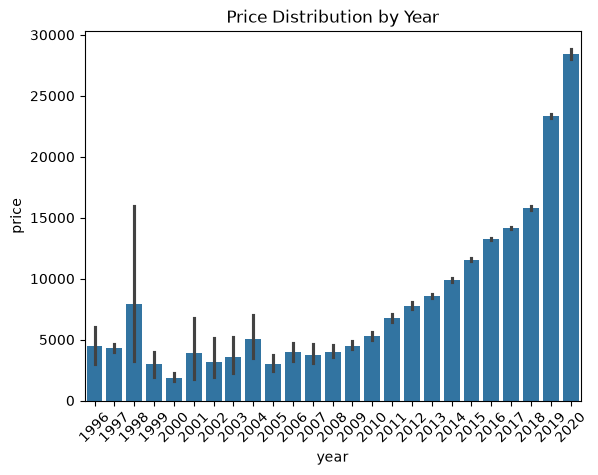

In [26]:
sns.barplot(x='year', y='price', data=df)
plt.title('Price Distribution by Year')
plt.xticks(rotation=45)
plt.show()

In [27]:
year_counts = df['year'].value_counts().sort_index()
print((year_counts / len(df) * 100).round(2))

year
1996     0.00
1997     0.00
1998     0.01
1999     0.01
2000     0.01
2001     0.01
2002     0.02
2003     0.03
2004     0.04
2005     0.07
2006     0.09
2007     0.16
2008     0.22
2009     0.31
2010     0.32
2011     0.44
2012     0.66
2013     2.75
2014     4.21
2015     7.71
2016    15.71
2017    22.40
2018    13.96
2019    26.27
2020     4.58
Name: count, dtype: float64


##  Conclusions :

*The plot immediately shows that cars from more recent years are more 
expensive. However, the trend is not perfectly smooth. We can see cars from 
1997 that cost more than cars from 2000 — probably collector or 
vintage cars, which follow a completely different market logic 
(rarity + historical value).*

*But in principle, the correlation between price and year of manufacture 
is a rising trend.*

*For the ML model, these vintage outliers could be problematic — a car 
from 1997 priced at £30k doesn't follow the general "older = cheaper" 
rule, and the model might learn the wrong pattern from these few examples.*

⚙️ 7. Engine Size vs Price
Bigger engines tend to cost more — is it true?

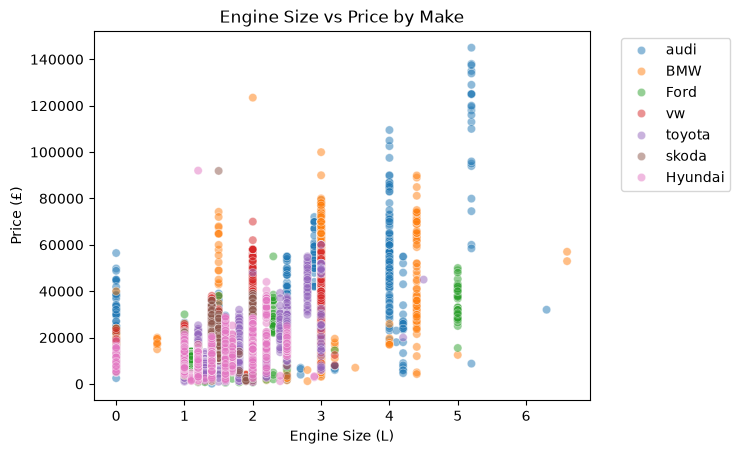

In [28]:
sns.scatterplot(x='engineSize', y='price', data=df, alpha=0.5, hue='Make', palette='tab10', legend='full')
plt.title('Engine Size vs Price by Make')
plt.xlabel('Engine Size (L)')
plt.ylabel('Price (£)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()

####  Conclusions :

*First thing I notice: Hyundai models have the lowest prices, with 
engine sizes between 0 (probably electric, or possibly missing values 
marked as 0) and ~2L — these are budget models. BMW sits mostly in 
the mid range, and Audi covers a wide range from small engines up 
to the big ones on their premium models.*

*The general trend is that bigger engines cost more, but the brand 
and model seem to be the more decisive factor for the price. For the 
same engine size, you can see huge price differences depending on the 
make — a 2.0L Audi is worth a lot more than a 2.0L Ford.*

🛣️ 8. MPG vs Price
Fuel efficiency vs cost.

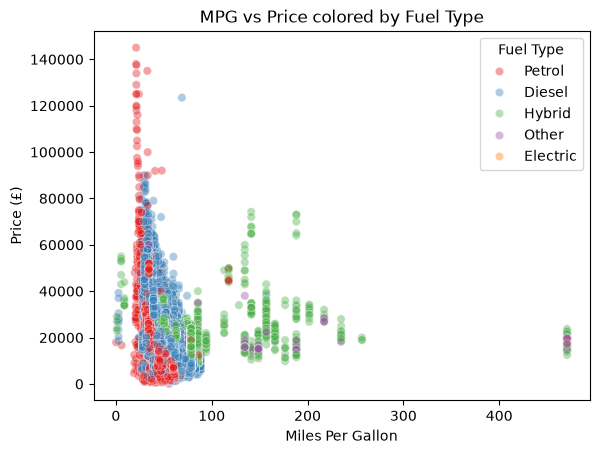

In [29]:
sns.scatterplot(x='mpg', y='price', data=df, alpha=0.4, hue='fuelType', palette='Set1')
plt.title('MPG vs Price colored by Fuel Type')
plt.xlabel('Miles Per Gallon')
plt.ylabel('Price (£)')
plt.legend(title='Fuel Type')
plt.show()

##  Conclusions :

*The first thing that caught my eye are the outliers past 400+ MPG — 
no normal car can do that many miles per gallon, so I've identified some 
data errors (or possibly plug-in hybrids measured in MPGe, which is a 
different metric).*

*Looking at the general pattern: hybrids have the highest MPG on average 
(lowest fuel consumption) because they also use electricity. Diesels are 
also fuel-efficient, sitting in the mid-to-high MPG range. Petrol cars
cover the widest range — from low MPG all the way up to expensive models 
reaching £140k in price.*

*For the ML model, those 400+ MPG outliers should probably be cleaned up — 
either removed or replaced with the median MPG for their fuel type. 
Otherwise, they could mislead the model into learning bad patterns.*

### Let's see how these are correlated to the price

📦 9. Correlation Heatmap
Find linear relationships between numeric features.

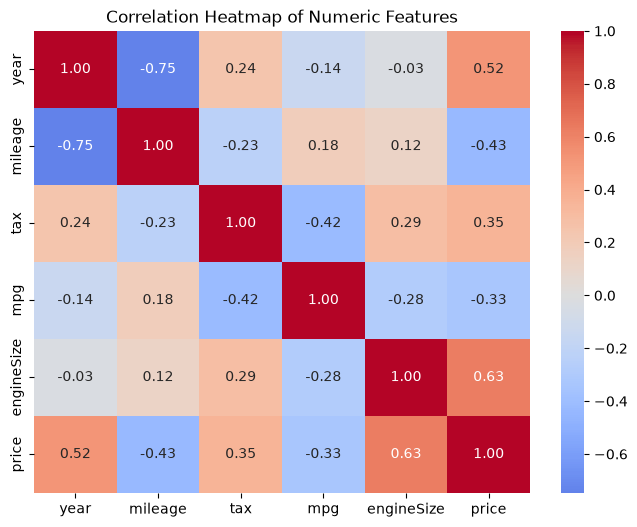

In [30]:
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [31]:
corr = df.corr(numeric_only=True)


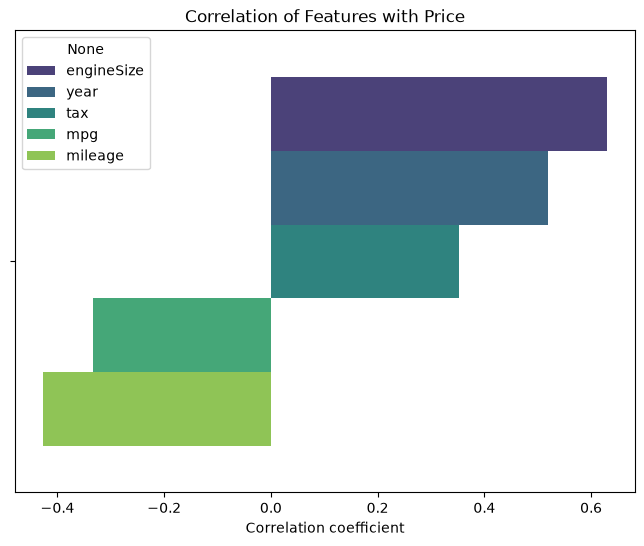

In [32]:

# Correlation with 'price' only
price_corr = corr['price'].sort_values(ascending=False)

# Drop 'price' itself for clarity
price_corr = price_corr.drop('price')

plt.figure(figsize=(8, 6))
sns.barplot(x=price_corr.values, hue=price_corr.index,  palette='viridis')
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation coefficient')
plt.show()

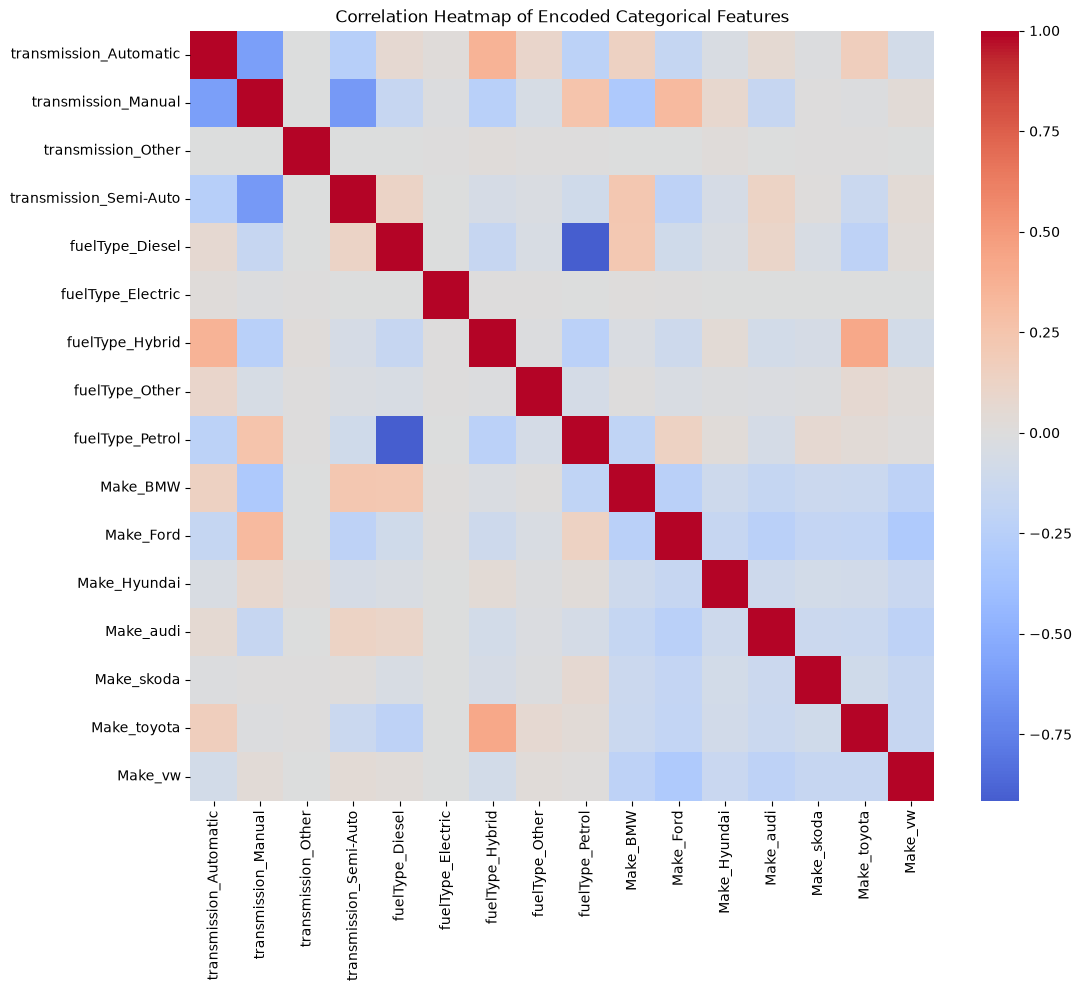

In [33]:
# Drop 'model' and encode categorical columns
df_no_model = df.drop(columns=['model'])
df_encoded = pd.get_dummies(df_no_model, columns=['transmission', 'fuelType', 'Make'])

# Select encoded categorical columns (exclude numeric)
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']
encoded_cols = [col for col in df_encoded.columns if col not in numeric_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded[encoded_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Encoded Categorical Features')
plt.show()

#### Ok, we have a lot of correlations here so we can draw a lot of conclusions. When a correlation is approaching to 1, it means that there is a strong correlation between two features, and they are directly proportional to one another. Where the correlation is close to 0, it does not indicate to much for us, no correlation. If the correlation is approaching to -1, it means that there is an inverse proportionality between those features: where one increases, the other one decreaases.

## 10 conclusions based on correlations

*1. transmission_Manual vs transmission_Automatic → ~-0.55 (blue). Strong 
negative correlation, but it's trivial by construction — a car can't be both 
manual and automatic at the same time.*

*2. fuelType_Hybrid vs transmission_Automatic → ~+0.4 (dark pink).
Positive correlation. Cars with automatic transmission tend to also run on 
electric power.*

*3. Make_Ford vs transmission_Manual → ~+0.57 (dark pink). Strong positive 
correlation. Ford produces a lot of cars with manual transmission, which fits 
their mass-market, budget-friendly positioning.*

*4. Make_BMW vs transmission_Manual → ~-0.33 (blue). Negative correlation. 
If BMW shows up on a row, it's unlikely to have a manual gearbox — BMW leans 
premium, so automatic/semi-auto dominates.*

*5. fuelType_Petrol vs fuelType_Diesel → ~-0.8 (dark blue). Strong 
negative correlation, but trivial — the two fuel types are mutually exclusive. 
The magnitude is high because there are only 3-4 fuel types, so they clash 
often in the dataset.*

*6. Make_Hyundai vs fuelType_Electric → ~+0.1 (white). No visible linear 
relationship between these attributes in the dataset.*

*7. Make_Toyota vs fuelType_Hybrid → dark pink. Strong positive 
correlation. This means Toyota produces a lot of hybrids, which matches 
reality — Toyota has been the hybrid pioneer since the Prius (1997).*

*8. Make_Toyota vs Make_Ford → ~-0.2 (light blue). Negative correlation, 
and actually quite strong even though the color isn't very deep. This happens 
because these brands appear rarely in the dataset, so many (0,0) pairs (when 
the car is another brand) dilute the correlation.*

*9. fuelType_Diesel vs transmission_Semi-Auto → ~+0.25 (light pink).
Weakly positive correlation. Diesel pairs well with semi-auto gearboxes , so a positive 
correlation is expected.*

*10. Make_BMW vs transmission_Other → ~+0.1 (white). No clear conclusion 
here — BMW being a premium brand doesn't use experimental or unusual 
transmissions, or if it does, we can't establish a linear relationship for 
those cars in this dataset.*

### Next steps:
- Feature Engineering: create new or transformed features that may better capture relationships (e.g. : Age of car: car_age = current_year - year, Binning mileage or engineSize into ranges, Log-transform skewed data (e.g., price, mileage), Interactions (e.g., mpg × engineSize))
- Encoding Categorical Features: perfect for transmission, fuelType, Make. Decide what to do with model column (high cardinality column)
- Feature Selection: 
     - You don't always want to keep everything. Good strategies include:
     - Use correlation with price (already done!)
     - SelectKBest, recursive feature elimination (RFE)
     - Model-based importance (e.g., .feature_importances_ from RandomForestRegressor)

#### Let's exemplify these two new features that were engineered based on already existing columns:

In [34]:
import datetime

current_year = datetime.datetime.now().year
df['car_age'] = current_year - df['year']

df[['year', 'car_age']].head()

,year,car_age
0,2017,9
1,2016,10
2,2016,10
3,2017,9
4,2019,7


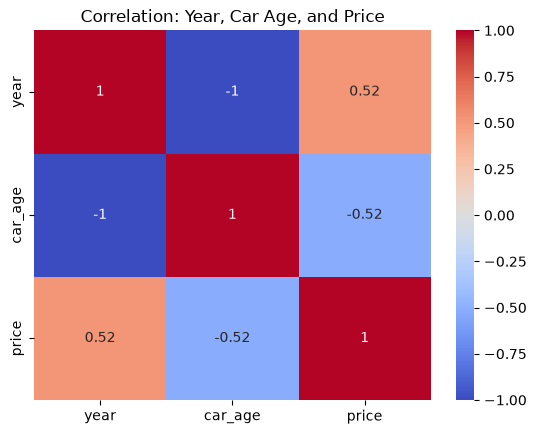

In [35]:
correlation_subset = df[['year', 'car_age', 'price']].corr()
sns.heatmap(correlation_subset, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Year, Car Age, and Price')
plt.show()

#### For example, it did not help. You can work with either car age or year, it gives the same stuff

In [36]:
# Define mileage bins
bins = [0, 10000, 30000, 60000, 100000, df['mileage'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# Check distribution
df['mileage_bin'].value_counts()

mileage_bin
Low          28207
Very Low     23584
Medium       15994
High          4060
Very High      590
Name: count, dtype: int64

#### Create bins for mileage

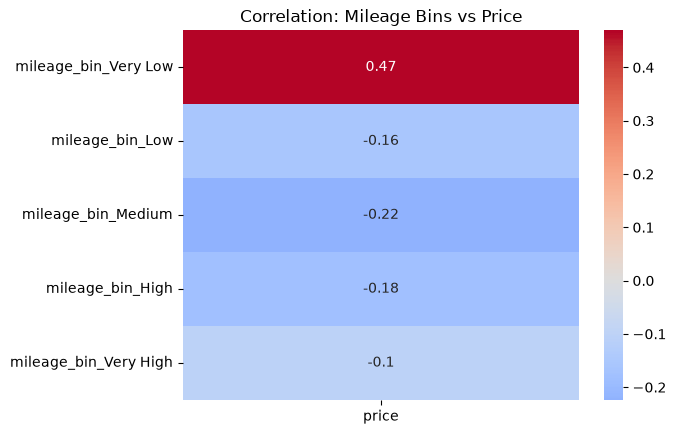

In [37]:
# 1. Define mileage bins
bins = [0, 10000, 30000, 60000, 100000, df['mileage'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# 2. One-hot encode the bin column
df_encoded_bins = pd.get_dummies(df[['mileage_bin', 'price']], drop_first=False)

# 3. Compute correlation matrix
corr_bins = df_encoded_bins.corr()

# 4. Show correlation of each bin with price
corr_with_price = corr_bins[['price']].drop('price')  # remove self-correlation

# 5. Plot
sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Mileage Bins vs Price')
plt.show()

*The correlation between the mileage bins and price is weak — only the "Very Low" bin shows a noticeable positive correlation, which just confirms what we already knew: low mileage cars tend to be more expensive. But the values are well below 0.5, so nothing significant enough to rely on.*

*The fundamental problem is that binning loses information. The original mileage column has precise values (15,735 km vs 36,203 km), while the bin just says "Low" for both. Two cars with 10,001 km and 29,999 km end up in the same category, even though the price difference between them could be huge.*

*Conclusion: binning mileage is not helpful here. The original continuous column already captures the relationship with price, and it does it more precisely. We'll stick with mileage and drop mileage_bin.*

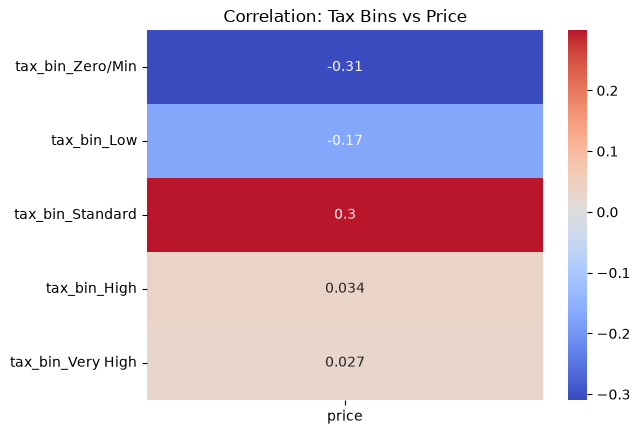

In [38]:
bins = [0, 20, 30, 145, 300, df['tax'].max()]
labels = ['Zero/Min', 'Low', 'Standard', 'High', 'Very High']
df['tax_bin'] = pd.cut(df['tax'], bins=bins, labels=labels, include_lowest=True)

# 2. One-hot encode the bin column
df_encoded_bins = pd.get_dummies(df[['tax_bin', 'price']], drop_first=False)

# 3. Compute correlation matrix
corr_bins = df_encoded_bins.corr()

# 4. Show correlation of each bin with price
corr_with_price = corr_bins[['price']].drop('price')  # remove self-correlation

# 5. Plot
sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Tax Bins vs Price')
plt.show()

*At first glance, `tax_bin_Zero/Min = -0.31` looks like it's saying expensive cars have low tax, which doesn't make sense. But that's not what it means — the negative correlation tells us that when a car falls into the Zero/Min tax group, its price tends to be lower. And it makes sense: cars with £0–£20 tax are typically older diesels, small engines, budget models.*

*On the other side, `tax_bin_Standard = 0.30` confirms that cars paying the standard £145 tax tend to be newer and pricier — that's the most common tax band for modern cars in the UK.*

*High and Very High bins show almost no correlation (~0.03), probably because there are too few cars in those groups to form any meaningful pattern.*

*Same conclusion as mileage bins: correlations are below 0.5, so tax binning doesn't bring enough value over the original continuous `tax` column. We'll keep `tax` as is.*

#### Let's go back to the dataset, since we have enough information

In [39]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age,mileage_bin,tax_bin
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi,9,Low,High
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi,10,Medium,Zero/Min
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi,10,Low,Low
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi,9,Low,Standard
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi,7,Very Low,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0,78.4,1.6,Hyundai,10,Low,Zero/Min
72431,I40,2015,7830,Manual,59508,Diesel,30,65.7,1.7,Hyundai,11,Medium,Low
72432,I10,2017,6830,Manual,13810,Petrol,20,60.1,1.0,Hyundai,9,Low,Zero/Min
72433,Tucson,2018,13994,Manual,23313,Petrol,145,44.8,1.6,Hyundai,8,Low,Standard


#### Categorical features need to be endoded

| Column         | Type             | Strategy                       | Notes                                    |
| -------------- | ---------------- | ------------------------------ | ---------------------------------------- |
| `transmission` | Categorical      | One-hot encoding               | Few categories                           |
| `fuelType`     | Categorical      | One-hot encoding               | Few categories                           |
| `Make`         | Categorical      | One-hot encoding               | Moderate number of brands (OK to encode) |
| `model`        | High-cardinality | Exclude or use target encoding | Too many unique values                   |
| `mileage_bin`  | Ordinal-ish      | Ordinal encoding or one-hot    | Low to high — either way works           |


In [40]:
mileage_bin_order = {'Very Low': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
df['mileage_bin_encoded'] = df['mileage_bin'].map(mileage_bin_order)

# Now create df_encoded, drop 'model' and 'mileage_bin' (keep mileage_bin_encoded)
df_encoded = df.drop(columns=['model', 'mileage_bin'])

# One-hot encode categorical variables (except mileage_bin_encoded which is numeric now)
df_encoded = pd.get_dummies(df_encoded, columns=['transmission', 'fuelType', 'Make'], drop_first=True)

In [41]:
df_encoded

,year,price,mileage,tax,mpg,engineSize,car_age,tax_bin,mileage_bin_encoded,transmission_Manual,...,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,9,High,1,True,...,False,False,False,True,False,False,True,False,False,False
1,2016,16500,36203,20,64.2,2.0,10,Zero/Min,2,False,...,False,False,False,False,False,False,True,False,False,False
2,2016,11000,29946,30,55.4,1.4,10,Low,1,True,...,False,False,False,True,False,False,True,False,False,False
3,2017,16800,25952,145,67.3,2.0,9,Standard,1,False,...,False,False,False,False,False,False,True,False,False,False
4,2019,17300,1998,145,49.6,1.0,7,Standard,0,True,...,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,10,Zero/Min,1,True,...,False,False,False,False,False,True,False,False,False,False
72431,2015,7830,59508,30,65.7,1.7,11,Low,2,True,...,False,False,False,False,False,True,False,False,False,False
72432,2017,6830,13810,20,60.1,1.0,9,Zero/Min,1,True,...,False,False,False,True,False,True,False,False,False,False
72433,2018,13994,23313,145,44.8,1.6,8,Standard,1,True,...,False,False,False,True,False,True,False,False,False,False


#### Feature selection:  I will drop car_age since it is not helpful and also model because it has that huge cardinality

#### We have to decide to use mileage or binned column, mileage_bin_encoded. For now, we will stick to the original column

In [42]:
columns_to_drop = ['model', 'car_age', 'mileage_bin_encoded']  
df_clean = df_encoded.drop(columns=columns_to_drop, errors='ignore')
df_clean

,year,price,mileage,tax,mpg,engineSize,tax_bin,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,High,True,False,False,False,False,False,True,False,False,True,False,False,False
1,2016,16500,36203,20,64.2,2.0,Zero/Min,False,False,False,False,False,False,False,False,False,True,False,False,False
2,2016,11000,29946,30,55.4,1.4,Low,True,False,False,False,False,False,True,False,False,True,False,False,False
3,2017,16800,25952,145,67.3,2.0,Standard,False,False,False,False,False,False,False,False,False,True,False,False,False
4,2019,17300,1998,145,49.6,1.0,Standard,True,False,False,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,Zero/Min,True,False,False,False,False,False,False,False,True,False,False,False,False
72431,2015,7830,59508,30,65.7,1.7,Low,True,False,False,False,False,False,False,False,True,False,False,False,False
72432,2017,6830,13810,20,60.1,1.0,Zero/Min,True,False,False,False,False,False,True,False,True,False,False,False,False
72433,2018,13994,23313,145,44.8,1.6,Standard,True,False,False,False,False,False,True,False,True,False,False,False,False


In [43]:
bool_cols = df_clean.select_dtypes(include=['bool']).columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [44]:
df_clean

,year,price,mileage,tax,mpg,engineSize,tax_bin,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,High,1,0,0,0,0,0,1,0,0,1,0,0,0
1,2016,16500,36203,20,64.2,2.0,Zero/Min,0,0,0,0,0,0,0,0,0,1,0,0,0
2,2016,11000,29946,30,55.4,1.4,Low,1,0,0,0,0,0,1,0,0,1,0,0,0
3,2017,16800,25952,145,67.3,2.0,Standard,0,0,0,0,0,0,0,0,0,1,0,0,0
4,2019,17300,1998,145,49.6,1.0,Standard,1,0,0,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,Zero/Min,1,0,0,0,0,0,0,0,1,0,0,0,0
72431,2015,7830,59508,30,65.7,1.7,Low,1,0,0,0,0,0,0,0,1,0,0,0,0
72432,2017,6830,13810,20,60.1,1.0,Zero/Min,1,0,0,0,0,0,1,0,1,0,0,0,0
72433,2018,13994,23313,145,44.8,1.6,Standard,1,0,0,0,0,0,1,0,1,0,0,0,0



| Technique           | What it does                            | When to use                                                                                                                                                         |
| ------------------- | --------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Standardization** | Centers data to mean=0, std=1 (z-score) | When features have different units/scales, and your model assumes normality or is sensitive to scale (e.g., linear regression, logistic regression, SVM, k-NN, PCA) |
| **Normalization**   | Scales data to \[0,1] range             | When you want features in same scale but not necessarily centered, often useful for neural networks, distance-based models                                          |


*Standardization and normalization are only needed when the model is sensitive to feature scale — Linear Regression, SVM, KNN, Neural Networks. For tree-based models like Random Forest or XGBoost, scaling is irrelevant because they split on thresholds, not distances.*

*When we do standardize, it must be applied to all numerical features at once — not just the ones with the largest range. The whole point is to bring everything to the same scale; standardizing only `mileage` while leaving `engineSize` (0–6.6) and `year` (1996–2020) untouched would still leave the features on different scales. It's all or nothing.*

*For this dataset, StandardScaler (z-score) is the better choice over Min-Max normalization. We have outliers in mileage (cars with 300k+ km) that would compress 99% of the data towards 0 in a [0,1] range. Z-score handles outliers more gracefully since it has no fixed bounds.*

*Important: these are different from per-column transformations like log (applied only to skewed columns), binning (applied only where the relationship is step-wise), or encoding (applied only to categorical features). Those are applied individually, wherever they make sense — not across the board.*


# Next Steps for Your ML Pipeline

### 1. Split data into training and testing sets
- Use `train_test_split` (e.g., 80% train, 20% test) to evaluate your model’s performance on unseen data.

In [45]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((57948, 19), (14487, 19), (57948,), (14487,))


### 2. (Optional) Further feature engineering or selection
- Try feature importance or recursive elimination to reduce noise.
- Experiment with polynomial features or interaction terms if it makes sense.

### 3. Choose machine learning model(s)
- Start simple: Linear Regression, Decision Trees, Random Forest, Gradient Boosting.
- For regression, consider models like:  
  - Linear Regression  
  - RandomForestRegressor  
  - XGBoost / LightGBM  
  - Support Vector Regression (SVR)

In [30]:
# Initialize and train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)


### 4. Cross-validation
- Use K-Fold Cross Validation (e.g., 5 or 10 folds) on training set for robust performance estimation.
- Tune hyperparameters via grid search or random search within CV.

### TODO: perform cross-validation and choose best model! Play with parameters

### 5. Train final model on full training data
- Once hyperparameters are set, train model on all training data.

In [31]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



### 6. Evaluate on test data
- Predict on test set.
- Calculate key metrics like:  
  - MAE (Mean Absolute Error)  
  - RMSE (Root Mean Squared Error)  
  - R² (Coefficient of Determination)


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 1321.57
RMSE: 2323.89
R²: 0.939


MAE (Mean Absolute Error) = 1321.57
On average, your model's predicted car prices are off by about $1,322 from the actual prices. This is a direct measure of average prediction error in the same units as price.

RMSE (Root Mean Squared Error) = 2323.89
RMSE penalizes larger errors more than MAE because it squares the errors before averaging. An RMSE of ~$2,324 means larger errors exist, but overall the predictions are quite close. RMSE is more sensitive to outliers.

R² (Coefficient of Determination) = 0.939
This means your model explains about 93.9% of the variance in car prices. The closer to 1, the better the model fits the data. So 0.939 is excellent — your model predicts prices very well.

### 7. Visualize results
- Plot predicted vs actual prices scatter plot.
- Residual plots to check errors.
- Feature importance plots (for tree-based models).
- Learning curves if needed (to check for overfitting/underfitting).

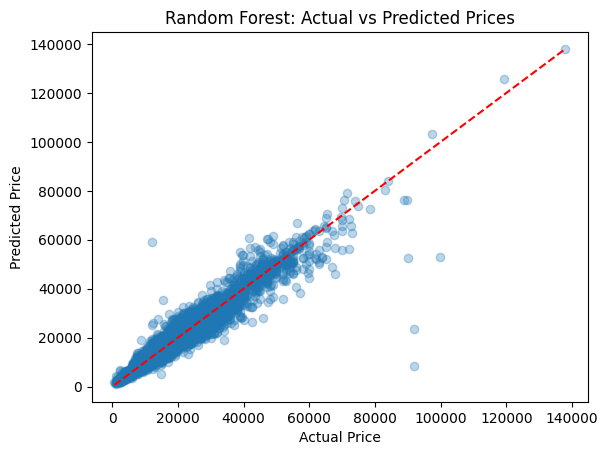

In [33]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

#### TODO: How well it fit the regression line?

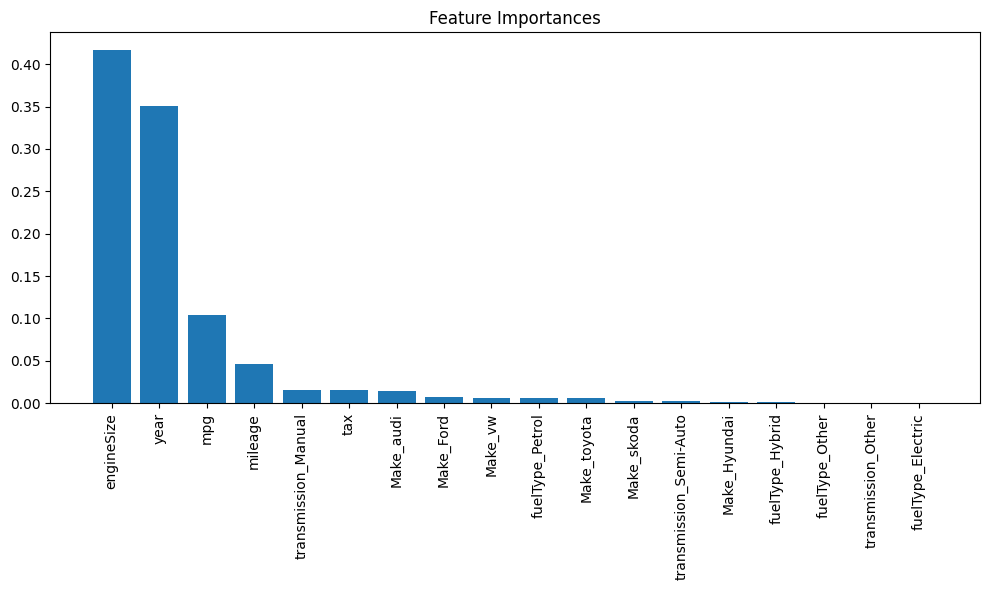

In [34]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()











### 8. Interpret and report
- Summarize model performance.
- Note any limitations or areas for improvement.

### 9. (Optional) Model improvement
- Try more advanced feature engineering.
- Try ensemble methods or stacking.
- Use domain knowledge for custom features.

### 10. Deployment (if needed)
- Prepare pipeline for new data.
- Save model using `joblib` or `pickle`.
